In [ ]:
import os
import numpy

In [ ]:
import zipfile
zip_path = "/content/project on CNN (1).zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(extract_path)

/content/


In [ ]:
!unrar x "/content/DATASET - LMS (3) (1).rar" "/content/"
print('/content/')


Streaming output truncated to the last 5000 lines.
Extracting  /content/DATASET/train/buildings/9925.jpg                     38%  OK 
Extracting  /content/DATASET/train/buildings/9929.jpg                     38%  OK 
Extracting  /content/DATASET/train/buildings/993.jpg                      38%  OK 
Extracting  /content/DATASET/train/buildings/9932.jpg                     38%  OK 
Extracting  /content/DATASET/train/buildings/9942.jpg                     38%  OK 
Extracting  /content/DATASET/train/buildings/9948.jpg                     38%  OK 
Extracting  /content/DATASET/train/buildings/9962.jpg                     38%  OK 
Extracting  /content/DATASET/train/buildings/9966.jpg                     38%  OK 
Creating    /content/DATASET/train/forest                             OK
Extracting  /content/DATASET/train/forest/10010.jpg                       38%  OK 
Extracting  /content/DATASET/train/forest/10020.

In [ ]:
import tensorflow as tf

train = tf.keras.utils.image_dataset_from_directory(
    "/content/DATASET/train",

    image_size = (256,256),
    batch_size = 32,
    shuffle = True)

test = tf.keras.utils.image_dataset_from_directory(
    "/content/DATASET/test",

    image_size = (256,256),
    batch_size = 32,
    shuffle = True)

val = tf.keras.utils.image_dataset_from_directory(
    "/content/DATASET/val",

    image_size = (256,256),
    batch_size = 32,
    shuffle = True)

Found 5387 files belonging to 3 classes.
Found 1421 files belonging to 3 classes.
Found 1349 files belonging to 3 classes.


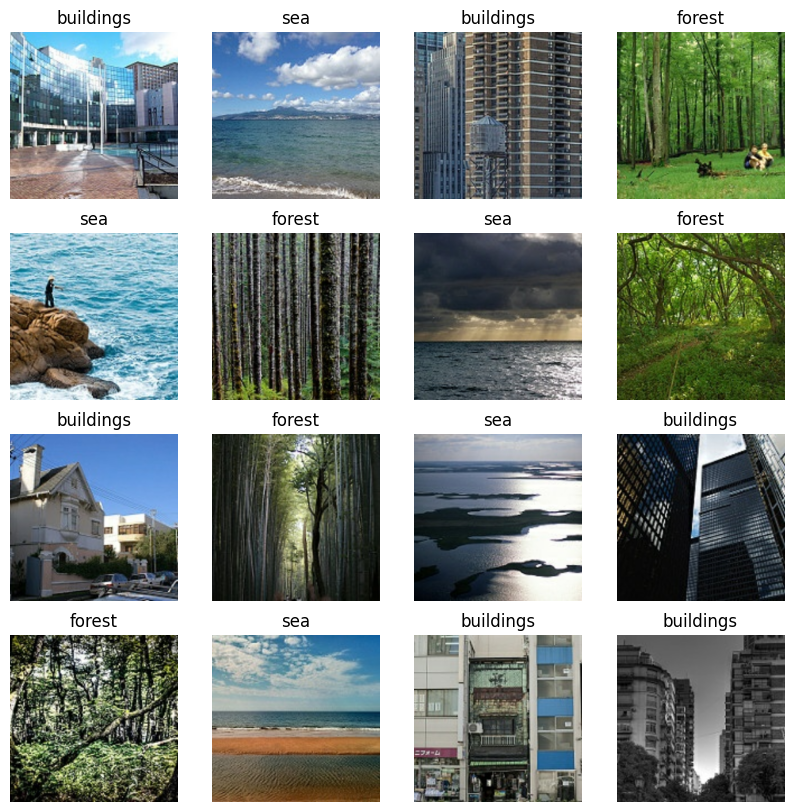

In [ ]:
import matplotlib.pyplot as plt

batch = next(iter(train))

fig,axes = plt.subplots(4,4,figsize = (10,10))
for i, ax in enumerate(axes.flat):
  ax.imshow(batch[0][i]/255.0)
  label_idx = batch[1][i].numpy()
  label_map = {i:name for i,name in enumerate(train.class_names)}
  ax.set_title(label_map[label_idx])
  ax.axis("off")
plt.show()

In [ ]:
normalize = tf.keras.layers.Rescaling(0.1/255.0)

train = train.map(lambda x,y:(normalize(x),y))
test = test.map(lambda x,y:(normalize(x),y))
val = val.map(lambda x,y:(normalize(x),y))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout,BatchNormalization

In [ ]:
import numpy as np
from collections import Counter

labels = []

for _, y in train:
    labels.extend(y.numpy())

print(Counter(labels))

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

In [ ]:
model = Sequential()

model.add(data_augmentation)
model.add(Conv2D(32,kernel_size=(3,3),activation = "relu",input_shape = (256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))
model.add(Conv2D(64,kernel_size=(3,3),activation = "relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
#model.add(Dense(128,activation = "relu"))
model.add(Dense(64,activation = "relu"))
model.add(Dense(3,activation = "softmax"))

model.compile(optimizer = "adam",loss = "sparse_categorical_crossentropy",metrics = ["accuracy"])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

early_stop = EarlyStopping(monitor = "val_loss",patience =5, restore_best_weights = True)
reduce_lr = ReduceLROnPlateau(monitor = "val_loss",patience = 3, factor = 0.5,min_lr = 1e-6)

In [ ]:
#model.compile(optimizer = "adam",loss = "sparse_categorical_crossentropy",metrics = ["accuracy"])

In [ ]:
model.fit(train,batch_size= 32 ,epochs = 30,validation_data = val)#,callbacks = [early_stop,reduce_lr])

Epoch 1/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 36s 157ms/step - accuracy: 0.7433 - loss: 1.2061 - val_accuracy: 0.3373 - val_loss: 1.0725
Epoch 2/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 26s 153ms/step - accuracy: 0.8580 - loss: 0.3617 - val_accuracy: 0.3388 - val_loss: 1.2270
Epoch 3/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 26s 153ms/step - accuracy: 0.8740 - loss: 0.3320 - val_accuracy: 0.5915 - val_loss: 0.9083
Epoch 4/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 26s 153ms/step - accuracy: 0.8788 - loss: 0.3154 - val_accuracy: 0.7383 - val_loss: 0.6307
Epoch 5/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 25s 151ms/step - accuracy: 0.8886 - loss: 0.3038 - val_accuracy: 0.9051 - val_loss: 0.2738
Epoch 6/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 25s 150ms/step - accuracy: 0.8957 - loss: 0.2751 - val_accuracy: 0.7932 - val_loss: 0.5611
Epoch 7/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 26s 151ms/step - accuracy: 0.9072 - loss: 0.2496 - val_accuracy: 0.9007 - val_loss: 0.2865
Epoch 8/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 25s 150ms/step - accuracy: 0.9042 - loss: 0

Counter({np.int32(2): 1819, np.int32(1): 1816, np.int32(0): 1752})
